<a href="https://colab.research.google.com/github/AtishArun/Party-Bingo/blob/main/Copy_of_Patient_Monitoring_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BLOCK 1 — IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# SHAP
import shap

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [ ]:
# ============================================================
# BLOCK 2 — LOAD AND EXPLORE DATASETS
# ============================================================

# --- Dataset 1: Synthetic ICU Data ---
df_synthetic = pd.read_csv('/ICU_Patient_Monitoring_Mortality_Prediction_15000.csv')
print("=== Synthetic Dataset ===")
print(f"Shape: {df_synthetic.shape}")
print(f"Mortality Rate: {df_synthetic['mortality_label'].mean()*100:.1f}%")
print(f"Missing Values: {df_synthetic.isnull().sum().sum()}")

# --- Dataset 2: GOSSIS Real ICU Data ---
df_gossis = pd.read_csv('/dataset.csv')
print("\n=== GOSSIS Real ICU Dataset ===")
print(f"Shape: {df_gossis.shape}")
print(f"Mortality Rate: {df_gossis['hospital_death'].mean()*100:.1f}%")
print(f"Total Missing Values: {df_gossis.isnull().sum().sum()}")

# --- Select relevant GOSSIS features ---
gossis_features = ['age', 'd1_heartrate_max', 'd1_heartrate_min',
                   'd1_sysbp_max', 'd1_sysbp_min', 'd1_resprate_max',
                   'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min',
                   'd1_temp_max', 'd1_temp_min', 'd1_glucose_max',
                   'map_apache', 'ventilated_apache', 'hospital_death']

df_gossis_clean = df_gossis[gossis_features].dropna()
print(f"\nGOSSIS after cleaning: {df_gossis_clean.shape}")
print(f"Mortality Rate after cleaning: {df_gossis_clean['hospital_death'].mean()*100:.1f}%")
print("\nDatasets loaded successfully ✅")

=== Synthetic Dataset ===
Shape: (15000, 24)
Mortality Rate: 22.8%
Missing Values: 0

=== GOSSIS Real ICU Dataset ===
Shape: (91713, 85)
Mortality Rate: 8.6%
Total Missing Values: 288046

GOSSIS after cleaning: (79707, 15)
Mortality Rate after cleaning: 8.3%

Datasets loaded successfully ✅


In [ ]:
# ============================================================
# BLOCK 3 — PREPROCESSING & FEATURE ENGINEERING
# ============================================================

# --- GOSSIS Features and Target ---
X = df_gossis_clean.drop('hospital_death', axis=1)
y = df_gossis_clean['hospital_death']

# --- Feature Engineering ---
X = X.copy()
X['hr_variability'] = X['d1_heartrate_max'] - X['d1_heartrate_min']
X['bp_variability'] = X['d1_sysbp_max'] - X['d1_sysbp_min']
X['shock_index'] = X['d1_heartrate_max'] / X['d1_sysbp_min'].replace(0, 1)
X['spo2_drop'] = X['d1_spo2_max'] - X['d1_spo2_min']
X['temp_variability'] = X['d1_temp_max'] - X['d1_temp_min']

print("Features after engineering:", X.shape[1])
print("New features added: hr_variability, bp_variability,")
print("                    shock_index, spo2_drop, temp_variability")

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# --- Scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Class Weight ---
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"\nTraining set: {X_train_scaled.shape}")
print(f"Testing set: {X_test_scaled.shape}")
print(f"Mortality rate - Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%")
print(f"Class weight ratio: {scale_weight:.2f}")
print("\nPreprocessing complete ✅")

Features after engineering: 19
New features added: hr_variability, bp_variability,
                    shock_index, spo2_drop, temp_variability

Training set: (63765, 19)
Testing set: (15942, 19)
Mortality rate - Train: 8.3% | Test: 8.3%
Class weight ratio: 11.05

Preprocessing complete ✅


=== Model Performance ===
              precision    recall  f1-score   support

           0       0.96      0.84      0.90     14620
           1       0.27      0.65      0.38      1322

    accuracy                           0.83     15942
   macro avg       0.62      0.75      0.64     15942
weighted avg       0.91      0.83      0.86     15942

AUC-ROC Score: 0.839


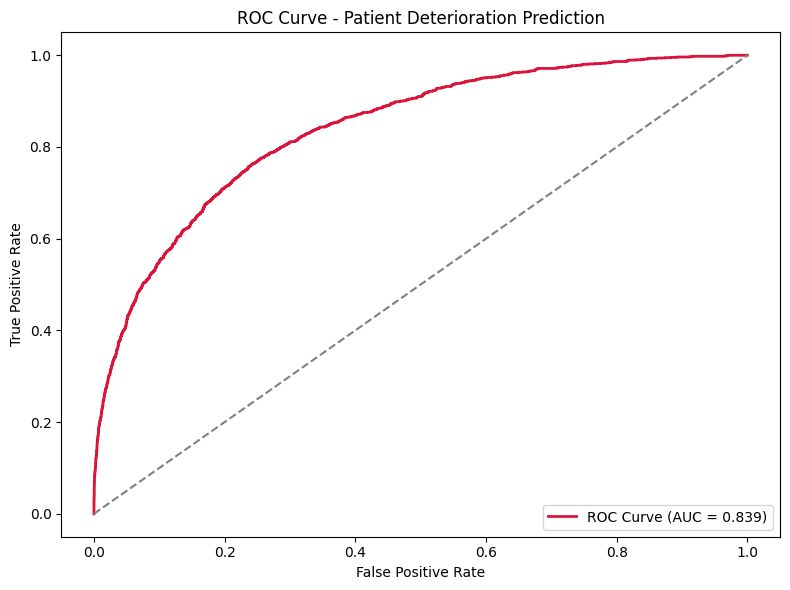

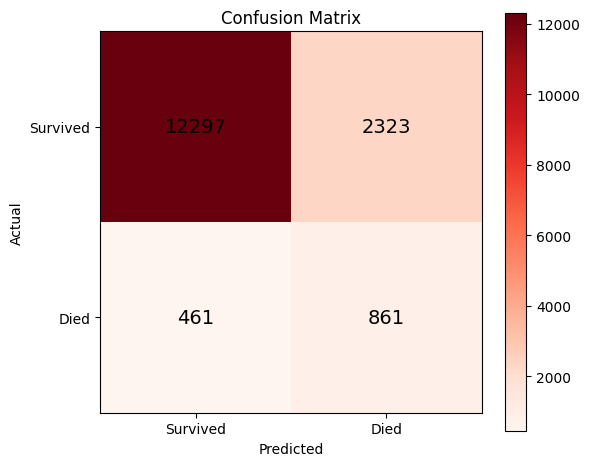


Model training and evaluation complete ✅


In [ ]:
# ============================================================
# BLOCK 4 — MODEL TRAINING & EVALUATION
# ============================================================

# --- Train XGBoost ---
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)

# --- Predictions ---
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# --- Classification Report ---
print("=== Model Performance ===")
print(classification_report(y_test, y_pred))
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2,
         label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Patient Deterioration Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Reds)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks([0, 1], ['Survived', 'Died'])
plt.yticks([0, 1], ['Survived', 'Died'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center',
                 va='center', color='black', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nModel training and evaluation complete ✅")

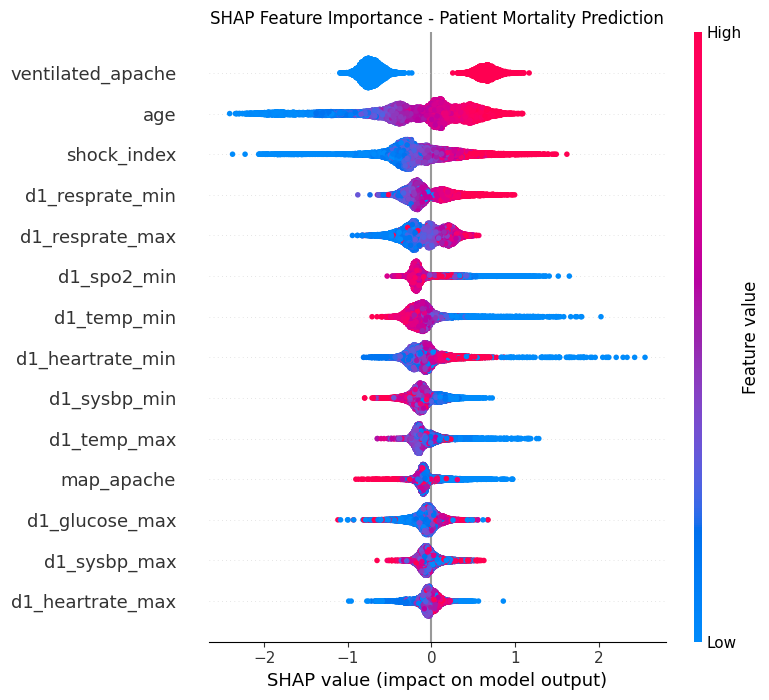

=== LIVE RISK SCORE DEMO ===

Patient #25
Risk Score:          82/100
Status:              🔴 CRITICAL
Mortality Prob:      82.9%
Actual Outcome:      Died
-----------------------------------
Patient #0
Risk Score:          13/100
Status:              🟢 STABLE
Mortality Prob:      13.2%
Actual Outcome:      Survived
-----------------------------------

System ready ✅


In [ ]:
# ============================================================
# BLOCK 5 — SHAP EXPLAINABILITY & RISK SCORE
# ============================================================

# --- SHAP Plot ---
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  max_display=14,
                  plot_type="dot",
                  show=False)
plt.title("SHAP Feature Importance - Patient Mortality Prediction")
plt.tight_layout()
plt.savefig('shap_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Risk Score Function ---
def get_risk_score(patient_index):
    patient = X_test.iloc[[patient_index]]
    actual = y_test.iloc[patient_index]
    probability = model.predict_proba(scaler.transform(patient))[0][1]
    risk_score = int(probability * 100)

    if risk_score < 30:
        status = "🟢 STABLE"
    elif risk_score < 60:
        status = "🟡 MONITOR"
    elif risk_score < 80:
        status = "🟠 ALERT"
    else:
        status = "🔴 CRITICAL"

    print(f"Patient #{patient_index}")
    print(f"Risk Score:          {risk_score}/100")
    print(f"Status:              {status}")
    print(f"Mortality Prob:      {probability:.1%}")
    print(f"Actual Outcome:      {'Died' if actual == 1 else 'Survived'}")
    print("-" * 35)
    return risk_score

# --- Demo: One who died, one who survived ---
print("=== LIVE RISK SCORE DEMO ===\n")
died_idx = X_test.index.get_loc(y_test[y_test == 1].index[0])
survived_idx = X_test.index.get_loc(y_test[y_test == 0].index[0])

get_risk_score(died_idx)
get_risk_score(survived_idx)

print("\nSystem ready ✅")

In [ ]:
# ============================================================
# BLOCK 6 — SAVE MODEL & SCALER
# ============================================================
import joblib

joblib.dump(model, 'patient_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X.columns), 'feature_names.pkl')

print("Model saved: patient_model.pkl ✅")
print("Scaler saved: scaler.pkl ✅")
print("Features saved: feature_names.pkl ✅")
print("\nDownload these 3 files for Streamlit deployment")

Model saved: patient_model.pkl ✅
Scaler saved: scaler.pkl ✅
Features saved: feature_names.pkl ✅

Download these 3 files for Streamlit deployment
